In [3]:
import os
import sys
import numpy as np
import time
import pickle
from torch import manual_seed
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from PIL import Image 

from scipy.ndimage import sobel, laplace
import matplotlib.pyplot as plt 

In [2]:
split = 0
rescaled_string = ''
variable_string = ''

with open(f'./artifacts/split_{split}_all_watermark{variable_string}_test{rescaled_string}.pkl', 'rb') as file:
    all_watermark_data = pickle.load(file)

with open(f'./artifacts/split_{split}_no_watermark{variable_string}_test{rescaled_string}.pkl', 'rb') as file:
    no_watermark_data = pickle.load(file)

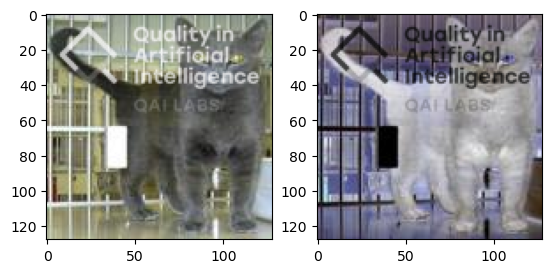

In [13]:
fig, axs = plt.subplots(1,2)

image_array = all_watermark_data[0][0]
inverted_image = image_array.copy()
inverted_image[:, :, :3] = 1 - inverted_image[:, :, :3]

axs[0].imshow(image_array)
axs[1].imshow(inverted_image)

In [15]:
import glob

glob.glob('./artifacts/split_0*')

['./artifacts/split_0_confounder_val.pkl',
 './artifacts/split_0_no_watermark_val.pkl',
 './artifacts/split_0_suppressor_val.pkl',
 './artifacts/split_0_suppressor_train.pkl',
 './artifacts/split_0_confounder_train.pkl',
 './artifacts/split_0_all_watermark_test.pkl',
 './artifacts/split_0_confounder_test.pkl',
 './artifacts/split_0_no_watermark_test.pkl',
 './artifacts/split_0_no_watermark_train.pkl',
 './artifacts/split_0_suppressor_test.pkl']

In [17]:
with open(f'./artifacts/split_{split}_confounder{variable_string}_test{rescaled_string}.pkl', 'rb') as file:
    conf_data = pickle.load(file)

In [40]:
len(conf_data)

3

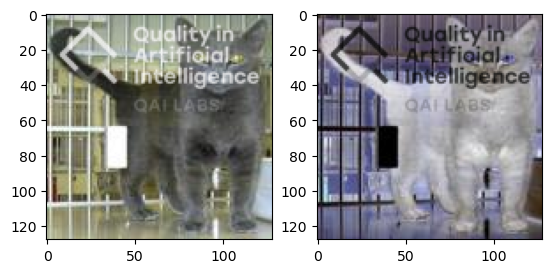

In [38]:
fig, axs = plt.subplots(1,2)

image_array = conf_data[0]

inverted_image = image_array.copy()
inverted_image[:, :, :, :3] = 1 - inverted_image[:, :, :, :3]

axs[0].imshow(image_array[0])
axs[1].imshow(inverted_image[0])

In [46]:

for file_path in glob.glob('./artifacts/split_0*'):
    if '_inverted' in file_path or '_rescaled' in file_path or '_variable' in file_path:
        continue
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    data_inverted = data[0].copy()
    data_inverted[:, :, :, :3] = 1 - data_inverted[:, :, :, :3]


    new_save = [data_inverted, data[1], data[2]]

    new_path = file_path.split('.pkl')[0] + '_inverted.pkl'

    with open(new_path, 'wb') as file:
        pickle.dump(new_save, file)

In [48]:
glob.glob('./artifacts/split_0*')

['./artifacts/split_0_no_watermark_train_inverted.pkl',
 './artifacts/split_0_confounder_val.pkl',
 './artifacts/split_0_no_watermark_val.pkl',
 './artifacts/split_0_suppressor_val.pkl',
 './artifacts/split_0_all_watermark_test_inverted.pkl',
 './artifacts/split_0_suppressor_train.pkl',
 './artifacts/split_0_confounder_test_inverted.pkl',
 './artifacts/split_0_confounder_train.pkl',
 './artifacts/split_0_no_watermark_val_inverted.pkl',
 './artifacts/split_0_suppressor_train_inverted.pkl',
 './artifacts/split_0_all_watermark_test.pkl',
 './artifacts/split_0_confounder_test.pkl',
 './artifacts/split_0_confounder_val_inverted.pkl',
 './artifacts/split_0_no_watermark_test.pkl',
 './artifacts/split_0_confounder_train_inverted.pkl',
 './artifacts/split_0_suppressor_val_inverted.pkl',
 './artifacts/split_0_no_watermark_train.pkl',
 './artifacts/split_0_no_watermark_test_inverted.pkl',
 './artifacts/split_0_confounder_val_inverted_inverted.pkl',
 './artifacts/split_0_suppressor_test.pkl',
 './

In [49]:
with open('./artifacts/split_0_confounder_test_inverted.pkl', 'rb') as file:
    data = pickle.load(file)

TRAINING

In [52]:
class Net(nn.Module):
    def __init__(self, num_classes=2):
        super(Net, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            )
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64*128*8, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 1028),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(1028, num_classes))
        
    def forward(self, x):
        out = self.layer1(x)
        # out = self.layer2(out)
        out = self.layer3(out)
        # out = self.layer4(out)
        out = self.layer5(out)
        # out = self.layer6(out)
        # out = self.layer7(out)
        #out = self.layer8(out)
        # out = self.layer9(out)
        # out = self.layer10(out)
        # out = self.layer11(out)
        # out = self.layer12(out)
        # out = self.layer13(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out


def train(lr,epochs,train_loader,val_loader,name_model,momentum=0.9,weight_decay=1e-3):
    for training_ind in range(1):
        SEEDS = [12031212,1234,5845389,23423,343495,2024,3842834,23402304,482347247,1029237127]

        SEED=SEEDS[training_ind] 

        manual_seed(SEED)

        np.random.seed(SEED)
        torch.manual_seed(SEED)

        os.environ['PYTHONHASHSEED']=str(SEED)

        random.seed(SEED)

        metric = AUROC(task='multiclass', num_classes=2) 
        metric_val = AUROC(task='multiclass', num_classes=2) 
        # softmax = nn.Softmax(dim=1)
        
        training_accuracy = Accuracy(task='multiclass', num_classes=2).to(DEVICE)
        val_accuracy = Accuracy(task='multiclass', num_classes=2).to(DEVICE)

        model=Net()
        model.to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)        

        min_loss = 1000000

        for epoch in range(epochs):  # loop over the dataset multiple times
            print(f' epoch {epoch+1} in {epochs}')
            t0=time.time()
            epoch_loss = 0.0
            epoch_loss_val= 0.0

            for i, data in enumerate(train_loader):
                inputs, labels = data

                inputs = inputs.to(DEVICE,dtype=torch.float)
                labels = labels.type(torch.LongTensor)
                labels=labels.to(DEVICE)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward + backward + optimize
                outputs = model(inputs).squeeze()
                _, predicted = torch.max(outputs.data, 1)

                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()        

                training_accuracy.update(predicted, labels)
                metric.update(outputs, labels.to(torch.int32))

            model.eval()
            with torch.no_grad():
                for i_v, data_val in enumerate(val_loader):
                    inputs_val, y_val = data_val

                    inputs_val = inputs_val.to(DEVICE,dtype=torch.float)
                    y_val = y_val.type(torch.LongTensor)
                    y_val=y_val.to(DEVICE)

                    outputs_val = model(inputs_val).squeeze()
                    _, predicted_val = torch.max(outputs_val.data, 1)

                    loss_val = criterion(outputs_val, y_val)

                    epoch_loss_val += loss_val.item() 

                    val_accuracy.update(predicted_val, y_val)
                    metric_val.update(outputs_val, y_val.to(torch.int32))
            
            model.train()

            auroc_train = metric.compute()
            auroc_val = metric_val.compute()

            epoch_acc = training_accuracy.compute()
            epoch_acc_val = val_accuracy.compute()

            if epoch_loss_val < min_loss:
                min_loss = epoch_loss_val
                save_model = type(model)() # get a new instance
                save_model.load_state_dict(model.state_dict()) # copy weights and stuff

                torch.save(save_model.state_dict(), f'{str(name_model)}_{training_ind}.pt')



            print(f'epoch train loss: {epoch_loss} | epoch train acc {epoch_acc} | AUROC: {auroc_train}')
            print(f'epoch val loss: {epoch_loss_val} | epoch val acc {epoch_acc_val} | AUROC: {auroc_val}')
            print(f'time elapsed: {round(time.time()-t0,2)} s')

            training_accuracy.reset()
            val_accuracy.reset()

            metric.reset()
            metric_val.reset()

            epoch_loss = 0.0
            epoch_loss_val=0.0

        print('Finished Training')
        print()
        print('\t \t *******************')
        print()

In [54]:
data[0].max()

np.float64(1.0)

In [59]:
import torch
from torch import manual_seed
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchmetrics import Accuracy,AUROC

DEVICE = torch.device("cuda",1)

# Training vars
batch_size=64
lr=0.005
epochs=100
weight_decay=0.001


for dataset in ['confounder','suppressor','no_watermark']:
    with open(f'./artifacts/split_0_{dataset}_train_inverted.pkl', 'rb') as f:
        x_train, y_train, _ = pickle.load(f)
        x_train = [[x.transpose(2,0,1),y_train.flatten()[i]] for i,x in enumerate(x_train)]
    print('train')

    with open(f'./artifacts/split_0_{dataset}_val_inverted.pkl', 'rb') as f:
        x_val, y_val, _ = pickle.load(f)
        x_val = [[x.transpose(2,0,1),y_val.flatten()[i]] for i,x in enumerate(x_val)]
    print('val')


    x_train_loader = DataLoader(x_train, batch_size=batch_size, shuffle=True)
    x_val_loader = DataLoader(x_val, batch_size=batch_size, shuffle=True)

    train(lr,epochs,x_train_loader,x_val_loader,f'./models/cnn_{dataset}_inverted_0',weight_decay=weight_decay)
    print(f'training done for {dataset} split number 0')

train
val
 epoch 1 in 100
epoch train loss: 68.00835251808167 | epoch train acc 0.7711904644966125 | AUROC: 0.8283481597900391
epoch val loss: 13.479982137680054 | epoch val acc 0.8050000071525574 | AUROC: 0.8792351484298706
time elapsed: 12.64 s
 epoch 2 in 100
epoch train loss: 58.63058239221573 | epoch train acc 0.8061904907226562 | AUROC: 0.8752481341362
epoch val loss: 13.80720004439354 | epoch val acc 0.7838888764381409 | AUROC: 0.8945231437683105
time elapsed: 10.14 s
 epoch 3 in 100
epoch train loss: 55.47357150912285 | epoch train acc 0.8148809671401978 | AUROC: 0.8887946605682373
epoch val loss: 12.628135174512863 | epoch val acc 0.8161110877990723 | AUROC: 0.8937604427337646
time elapsed: 13.43 s
 epoch 4 in 100
epoch train loss: 50.84943164885044 | epoch train acc 0.8295238018035889 | AUROC: 0.907578706741333
epoch val loss: 14.26101203262806 | epoch val acc 0.778333306312561 | AUROC: 0.8917012214660645
time elapsed: 10.22 s
 epoch 5 in 100
epoch train loss: 48.379868373274

# Explanations

In [60]:
from captum.attr import IntegratedGradients, GradientShap, Deconvolution, LRP, Lime

from zennit.composites import EpsilonAlpha2Beta1
from scipy.ndimage import sobel, laplace

In [103]:
def rescale_values(image,max_val,min_val):
    '''
    image - numpy array
    max_val/min_val - float
    '''
    return (image-image.min())/(image.max()-image.min())*(max_val-min_val)+min_val

with open(f'./artifacts/split_0_all_watermark_test_inverted.pkl', 'rb') as file:
    watermark_dataset = pickle.load(file)

with open(f'./artifacts/split_0_no_watermark_test_inverted.pkl', 'rb') as file:
    no_watermark_dataset = pickle.load(file)



folder=os.getcwd()
watermark_path=folder+'/watermark banner.jpg'
watermark = Image.open(watermark_path)
w=int(watermark_dataset[0][0].shape[1])
h=int(watermark.size[1]*w/watermark.size[0])
watermark = watermark.resize((w,h))
watermark=np.array(watermark)
rgb=rescale_values(watermark,1,0)
r, g, blue = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
gray = 1-(0.2989 * r + 0.5870 * g + 0.1140 * blue)
white=np.ones((w,w))
white[0:gray.shape[0],0:gray.shape[1]]=gray

fixed_mask = 1.0 * (white<1)

def lrp(data,model,target,device):
    # create a composite instance
    #composite = EpsilonPlusFlat()
    composite = EpsilonAlpha2Beta1()

    # use the following instead to ignore bias for the relevance
    # composite = EpsilonPlusFlat(zero_params='bias')

    # make sure the input requires a gradient
    data.requires_grad = True

    # compute the output and gradient within the composite's context
    with composite.context(model) as modified_model:
        modified_model=modified_model.to(device)
        output = modified_model(data.to(device)).to(device)

        grad = torch.eye(2, device=device)[[target]].to(device)
        # gradient/ relevance wrt. class/output 0
        output.backward(gradient=grad)
        # relevance is not accumulated in .grad if using torch.autograd.grad
        # relevance, = torch.autograd.grad(output, input, torch.eye(10)[[0])

    # gradient is accumulated in input.grad
    att=data.grad.detach().cpu().squeeze().numpy().transpose(1,2,0)

    # rgb_weights = [0.2989, 0.5870, 0.1140]
    # grayscale_att_lrp = np.dot(att[...,:3], rgb_weights)

    
    return att

def plot_atts(data,model,target):
    # data is a tensor of shape torch.Size([1, 3, 128, 128])
    # model is
    # target is an integer
    
    torch.manual_seed(SEED)
    out=model(data)
    Y_probs = F.softmax(out[0], dim=-1)

    target = int(target)
    
    ig_att = np.transpose(IntegratedGradients(model).attribute(data, target=target).squeeze().cpu().detach().numpy(), (1, 2, 0)).squeeze()
    gradshap_att = np.transpose(GradientShap(model).attribute(data,target=target, baselines=torch.zeros(data.shape).to(DEVICE)).squeeze().cpu().detach().numpy(), (1, 2, 0)).squeeze()
    deconv_att = np.transpose(Deconvolution(model).attribute(data,target=target).squeeze().cpu().detach().numpy(), (1, 2, 0)).squeeze()
    lrp_att=np.transpose(LRP(model).attribute(data,target=target).squeeze().cpu().detach().numpy(), (1, 2, 0)).squeeze()
    
    lrp_ab = lrp(data,model,target, DEVICE)
    rgb_weights = [0.2989, 0.5870, 0.1140]
    
    grayscale_att_deconv = np.dot(deconv_att[...,:3], rgb_weights)
    # grayscale_att_ix = np.dot(ix_att[...,:3], rgb_weights)
    # grayscale_att_backprp = np.dot(backprop_att[...,:3], rgb_weights)
    grayscale_att_shap = np.dot(gradshap_att[...,:3], rgb_weights)
    # grayscale_att_sal = np.dot(sal_att[...,:3], rgb_weights)
    grayscale_att_ig = np.dot(ig_att[...,:3], rgb_weights)
    grayscale_att_lrp = np.dot(lrp_att[...,:3], rgb_weights)
    # grayscale_att_lime = np.dot(lime_att[...,:3], rgb_weights)
    
    
    # atts={
    #     'deconv':abs(grayscale_att_deconv),
    #     #   'saliency':abs(grayscale_att_sal),
    #       'int_grads':abs(grayscale_att_ig),
    #       'shap':abs(grayscale_att_shap),
    #     #   'backprop':abs(grayscale_att_backprp),
    #     #   'ix':abs(grayscale_att_ix),
    #       'lrp':abs(grayscale_att_lrp), 
    #       'lrp_ab':abs(lrp_ab)
    #       # 'lime': abs(grayscale_att_lime)
    #       }

    atts_rgb={
        'deconv':deconv_att,
          'int_grads':ig_att,
          'shap':gradshap_att,
          'lrp':lrp_att, 
          'lrp_ab':lrp_ab
          }
    
    return atts_rgb,Y_probs


def load_trained(path):
    model = Net()
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    return model


def energy(att, watermark):
    if att.shape != watermark.shape:
        print('att shape', att.shape, 'watermark shape', watermark.shape)
        import sys
        sys.exit(0)
    
    image_size=att.shape[0]*att.shape[1]
    watermark_size=np.sum(watermark)
    
    watermark_att=att*watermark
    watermark_energy=np.sum(watermark_att)
    
    image_energy=np.sum(att)

    
    # Gives energy(watermark) = 7.858
    energy=(watermark_energy/watermark_size)/(image_energy/image_size)
    
    # Gives energy(watermark) = 1.0
    # energy = (np.sum(att*bin_water)/att.shape[0]*att.shape[1]) / (np.sum(att)/att.shape[0]*att.shape[1])
    
    return energy

In [105]:
# combines a 3 channel array according to rgb to greyscale conversion [R,G,B] = [0.2989, 0.5870, 0.1140]
def combine_rgb(arr, rgb_weights=[0.2989, 0.5870, 0.1140]):
    return np.abs(np.dot(arr[...,:3], rgb_weights))

# combines as per an equal weighting 1/3(abs(R) + abs(B) + abs(G))
def combine_norm(arr):
    return np.mean(np.abs(arr), axis=2)
    

In [169]:
SEEDS = [12031212,1234,5845389,23423,343495,2024,3842834,23402304,482347247,1029237127]
SEED=SEEDS[0] 

# original rgb comb 
energy_water_conf={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}
energy_water_sup={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}
energy_water_no={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}

energy_no_water_conf={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': [],}
energy_no_water_sup={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': []}
energy_no_water_no={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': []}


# 3 channels combined by new norm combination method
energy_water_conf_norm={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}
energy_water_sup_norm={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}
energy_water_no_norm={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}

energy_no_water_conf_norm={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': [],}
energy_no_water_sup_norm={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': []}
energy_no_water_no_norm={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': []}


explanations_water_conf={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}
explanations_water_sup={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}
explanations_water_no={'deconv':[],'int_grads':[],'shap':[],'lrp':[], 'lrp_ab': []}

explanations_no_water_conf={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': [],}
explanations_no_water_sup={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': []}
explanations_no_water_no={'deconv':[], 'int_grads':[], 'shap':[], 'lrp':[], 'lrp_ab': []}


model_conf=load_trained(f'./models/cnn_confounder_inverted_0_0.pt').eval().to(DEVICE)
model_sup=load_trained(f'./models/cnn_suppressor_inverted_0_0.pt').eval().to(DEVICE)
model_no=load_trained(f'./models/cnn_no_watermark_inverted_0_0.pt').eval().to(DEVICE)

folder=os.getcwd()+'/images'
print(folder)
t0=time.time()

N_test = 1800

wm_avg = np.zeros((N_test,3,128,128))
no_wm_avg = np.zeros((N_test,3,128,128))

for i in range(N_test):
    wm_avg[i] = watermark_dataset[0][i].transpose(2,0,1)
    no_wm_avg[i] = no_watermark_dataset[0][i].transpose(2,0,1)
    
wm_avg = np.mean(wm_avg, axis=0)
no_wm_avg = np.mean(no_wm_avg, axis=0)

rgb_weights = [0.2989, 0.5870, 0.1140]


res = {
    'laplace': [[], []],
    'sobel': [[], []],
    'x': [[], []]
}

for i in range(watermark_dataset[0].shape[0])[:N_test]:
    w_image = watermark_dataset[0][i]
    w_target=watermark_dataset[1][i]
    # w_image=w_image[0]
    # print(w_image.shape)
    # print(np.transpose(w_image, (2,0,1)).shape)
    w_example=torch.tensor(np.transpose(w_image, (2,0,1))).unsqueeze(0).to(DEVICE,dtype=torch.float)

    w_target_conf = torch.max(model_conf(w_example), 1)[1].to(int)
    w_target_sup = torch.max(model_sup(w_example), 1)[1].to(int)
    w_target_no = torch.max(model_no(w_example), 1)[1].to(int)

    nw_image = no_watermark_dataset[0][i]
    nw_target=no_watermark_dataset[1][i]
    # nw_image=nw_image[0]
    nw_example=torch.tensor(np.transpose(nw_image, (2,0,1))).unsqueeze(0).to(DEVICE,dtype=torch.float)

    nw_target_conf = torch.max(model_conf(nw_example), 1)[1].to(int)
    nw_target_sup = torch.max(model_sup(nw_example), 1)[1].to(int)
    nw_target_no = torch.max(model_no(nw_example), 1)[1].to(int)

    # explanations for predicted class (n)w_target_{MODEL}
    a_conf_w,_=plot_atts(w_example,model_conf,w_target_conf)
    a_sup_w,_=plot_atts(w_example,model_sup,w_target_sup)
    a_no_w,_=plot_atts(w_example,model_no,w_target_no)

    a_conf_nw,_=plot_atts(nw_example,model_conf,nw_target_conf)
    a_sup_nw,_=plot_atts(nw_example,model_sup,nw_target_sup)
    a_no_nw,_=plot_atts(nw_example,model_no,nw_target_no)

    watermark = fixed_mask
    # if sys.argv[3] == 'variable':
    #     watermark = masks_wm[i]

    for method in list(energy_water_conf.keys()):
        energy_water_conf[method].append(energy(combine_rgb(a_conf_w[method]), watermark))
        energy_water_sup[method].append(energy(combine_rgb(a_sup_w[method]), watermark))
        energy_water_no[method].append(energy(combine_rgb(a_no_w[method]), watermark))
    
        energy_no_water_conf[method].append(energy(combine_rgb(a_conf_nw[method]), watermark))
        energy_no_water_sup[method].append(energy(combine_rgb(a_sup_nw[method]), watermark))
        energy_no_water_no[method].append(energy(combine_rgb(a_no_nw[method]), watermark))

        
        energy_water_conf_norm[method].append(energy(combine_norm(a_conf_w[method]), watermark))
        energy_water_sup_norm[method].append(energy(combine_norm(a_sup_w[method]), watermark))
        energy_water_no_norm[method].append(energy(combine_norm(a_no_w[method]), watermark))
    
        energy_no_water_conf_norm[method].append(energy(combine_norm(a_conf_nw[method]), watermark))
        energy_no_water_sup_norm[method].append(energy(combine_norm(a_sup_nw[method]), watermark))
        energy_no_water_no_norm[method].append(energy(combine_norm(a_no_nw[method]), watermark))

        explanations_water_conf[method].append(a_conf_w[method])
        explanations_water_sup[method].append(a_sup_w[method])
        explanations_water_no[method].append(a_no_w[method])

        explanations_no_water_conf[method].append(a_conf_nw[method])
        explanations_no_water_sup[method].append(a_sup_nw[method])
        explanations_no_water_no[method].append(a_no_nw[method])

    # print(np.dot(np.abs(w_image).copy().transpose(1,2,0)[...,:3], rgb_weights).shape)
    x_wm = energy(np.dot(np.abs(w_image).copy()[...,:3], rgb_weights), watermark)
    x_no = energy(np.dot(np.abs(nw_image).copy()[...,:3], rgb_weights), watermark)

    sample = w_image.copy() - wm_avg.transpose(1,2,0)
    img_r = sample[:,:,0]
    img_g = sample[:,:,1]
    img_b = sample[:,:,2]
    
    lapl_wm = energy(np.abs(laplace(img_r)) + np.abs(laplace(img_g)) + np.abs(laplace(img_b)), watermark)
    sob_wm = energy(np.abs(sobel(img_r)) + np.abs(sobel(img_g)) + np.abs(sobel(img_b)), watermark)

    # nw_image.append(energy(np.dot(nw_image.copy().transpose(1,2,0)[...,:3], rgb_weights)))
    
    sample = nw_image.copy() - no_wm_avg.transpose(1,2,0)
    img_r = sample[:,:,0]
    img_g = sample[:,:,1]
    img_b = sample[:,:,2]
    
    lapl_no = energy(np.abs(laplace(img_r)) + np.abs(laplace(img_g)) + np.abs(laplace(img_b)), watermark)
    sob_no = energy(np.abs(sobel(img_r)) + np.abs(sobel(img_g)) + np.abs(sobel(img_b)), watermark)
    

    res['laplace'][0].append(lapl_wm)
    res['laplace'][1].append(lapl_no)
    res['sobel'][0].append(sob_wm)
    res['sobel'][1].append(sob_no)
    res['x'][0].append(x_wm)
    res['x'][1].append(x_no)

    if i==0 or (i%100)==0:
        print(i, 'out of', watermark_dataset[0].shape[0])
        print(time.time()-t0)
        # t0=time.time()
    

for baseline, results in res.items():
    energy_water_conf[baseline] = results[0]
    energy_no_water_conf[baseline] = results[1]

    energy_water_sup[baseline] = results[0]
    energy_no_water_sup[baseline] = results[1]

    energy_water_no[baseline] = results[0]
    energy_no_water_no[baseline] = results[1]


    energy_water_conf_norm[baseline] = results[0]
    energy_no_water_conf_norm[baseline] = results[1]

    energy_water_sup_norm[baseline] = results[0]
    energy_no_water_sup_norm[baseline] = results[1]

    energy_water_no_norm[baseline] = results[0]
    energy_no_water_no_norm[baseline] = results[1]

/home/clark01/debugging_xai/images


/home/clark01/mambaforge/envs/debugging/lib/python3.13/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/home/clark01/mambaforge/envs/debugging/lib/python3.13/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:64: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


0 out of 3
0.7940373420715332
100 out of 3
45.97022366523743
200 out of 3
89.87581872940063
300 out of 3
133.37287044525146
400 out of 3
179.40249133110046
500 out of 3
224.13128900527954
600 out of 3
267.1301021575928
700 out of 3
311.6395049095154
800 out of 3
357.82150411605835
900 out of 3
402.9680094718933
1000 out of 3
447.6368477344513
1100 out of 3
492.89811611175537
1200 out of 3
538.402694940567
1300 out of 3
584.3671276569366
1400 out of 3
629.4189624786377
1500 out of 3
675.1062762737274
1600 out of 3
719.7064859867096
1700 out of 3
763.5210781097412


In [172]:
energy_no_water_no.keys()

dict_keys(['deconv', 'int_grads', 'shap', 'lrp', 'lrp_ab', 'laplace', 'sobel', 'x'])

# Plots

In [179]:
# Load and arrange all results for plotting
def get_energies(input_energies):

    energy_water_conf = input_energies[0]
    energy_water_sup = input_energies[1]
    energy_water_no = input_energies[2]

    energy_no_water_conf = input_energies[3]
    energy_no_water_sup = input_energies[4]
    energy_no_water_no = input_energies[5]

    
    
    energies=[]
    methods = ['deconv', 'int_grads', 'shap', 'lrp', 'lrp_ab', 'laplace', 'sobel', 'x'] # lime just nan values
    n_test = 1800
    
    # energy_files = ['energy_water_conf_cat', 'energy_water_conf_dog', 'energy_water_sup', 'energy_water_no', 'energy_no_water_conf_cat', 'energy_no_water_conf_dog', 'energy_no_water_sup', 'energy_no_water_no']
    
    
    energies_dict = {}
    
    for method in methods:
        energies_dict[method] = {}
        comb_water_conf_cat = []
        comb_water_conf_dog = []
        comb_water_sup = []
        comb_water_no = []
        
        comb_no_water_conf_cat = []
        comb_no_water_conf_dog = []
        comb_no_water_sup = []
        comb_no_water_no = []
    
        # for file in energy_files:
        #     energies_dict[method][file] = []
    
        for split in range(1):
            
            labels = watermark_dataset[1]
            print(len(labels))
            
            for model_ind in range(1):
                water_conf = energy_water_conf[method][:n_test]
                no_water_conf = energy_no_water_conf[method][:n_test]
            
                # cat labels = 0, dog = 1; 20% cat with WM, 80% dog with WM
                water_conf_cat = np.asarray(water_conf)[np.where(labels == 0)[0]] 
                no_water_conf_cat = np.asarray(no_water_conf)[np.where(labels == 0)[0]] 
                
                water_conf_dog = np.asarray(water_conf)[np.where(labels == 1)[0]] 
                no_water_conf_dog = np.asarray(no_water_conf)[np.where(labels == 1)[0]] 
                
                comb_water_conf_cat.extend(water_conf_cat)
                comb_water_conf_dog.extend(water_conf_dog)
                
                comb_water_sup.extend(energy_water_sup[method][:n_test])
        
                if method == 'laplace' or method == 'sobel' or method == 'x':
                    comb_water_no.extend(energy_water_sup[method][:n_test])
                    comb_no_water_conf_cat.extend(np.asarray(energy_no_water_sup[method][:n_test])[np.where(labels == 0)[0]] )
                    comb_no_water_conf_dog.extend(np.asarray(energy_no_water_sup[method][:n_test])[np.where(labels == 1)[0]] )
    
                    # comb_no_water_conf_cat.extend(no_water_conf_cat)
                    # comb_no_water_conf_dog.extend(no_water_conf_dog)
                else:
                    comb_water_no.extend(energy_water_no[method][:n_test])
                    comb_no_water_conf_cat.extend(no_water_conf_cat)
                    comb_no_water_conf_dog.extend(no_water_conf_dog)
                    
        
                # comb_no_water_conf.extend(energy_no_water_conf[method][:n_test])
                comb_no_water_sup.extend(energy_no_water_sup[method][:n_test])
                comb_no_water_no.extend(energy_no_water_no[method][:n_test])
    
        # energy_files = ['energy_water_conf_cat', 'energy_water_conf_dog', 'energy_water_sup', 'energy_water_no', 'energy_no_water_conf_cat', 'energy_no_water_conf_dog', 'energy_no_water_sup', 'energy_no_water_no']
    
        energies_dict[method]['energy_water_conf_cat'] = np.array(comb_water_conf_cat)
        energies_dict[method]['energy_water_conf_dog'] = np.array(comb_water_conf_dog)
        energies_dict[method]['energy_water_sup'] = np.array(comb_water_sup)
        energies_dict[method]['energy_water_no'] = np.array(comb_water_no)
    
        energies_dict[method]['energy_no_water_conf_cat'] = np.array(comb_no_water_conf_cat)
        energies_dict[method]['energy_no_water_conf_dog'] = np.array(comb_no_water_conf_dog)
        energies_dict[method]['energy_no_water_sup'] = np.array(comb_no_water_sup)
        energies_dict[method]['energy_no_water_no'] = np.array(comb_no_water_no) 
        
        energies.append([[comb_no_water_conf_cat, comb_water_conf_cat],
                    [comb_no_water_conf_dog, comb_water_conf_dog],
                    [comb_no_water_sup, comb_water_sup],
                    [comb_no_water_no, comb_water_no]])

    return energies


In [187]:
def plot_watermarks_energies(energies, variable=False, rescaled=False, norm=False):
    import seaborn as sns
    variable_string = ''
    rescaled_string = ''
    if variable:
        variable_string = '_variable'

    if rescaled:
        rescaled_string = '_rescaled'

    method_inds = [0,1,2,3,4,5,6,7]
    
    fig, axs = plt.subplots(4, len(method_inds), figsize=(36, 15))
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    font_size=25
    plt.rcParams['font.size'] = font_size
    plt.rc('axes', titlesize=font_size) #title
    
    
    for i in range(4): #model
    #     for j in range(8): #method
        j = 0
        for method_ind in method_inds: #method
            #ex: energies[method][train][variant]
            if np.isnan(energies[method_ind][i][0]).any() or np.isinf(energies[method_ind][i][0]).any():
                print('energies 0:', method_ind, i)

            if np.isnan(energies[method_ind][i][1]).any() or np.isinf(energies[method_ind][i][1]).any():
                print('energies 1:', method_ind, i)
                
            g=sns.histplot(ax=axs[i, j],data=[energies[method_ind][i][0],energies[method_ind][i][1]],bins=100)
            axs[i, j].legend([],[], frameon=False)
            axs[i,j].set_ylabel('')
    #         axs[i,j].set_ylim(0,200)
            
            # if i!=3:
            #     axs[i,j].set_xticks([])

            axs[i, j].set_xlim(0,3)
            axs[i, j].set_xticks([0,1,2,3])
        
            if j!=0:
                axs[i,j].set_yticks([])
                
            j+=1

        # energies_wm, energies_no, x_cat, x_dog  = get_energies_x(fixed_mask, variable=variable, rescaled=rescaled)

        # if i == 0:
        #     g=sns.histplot(ax=axs[i, j],data=x_cat,bins=100)
        # elif i == 1:
        #     g=sns.histplot(ax=axs[i, j],data=x_dog,bins=100)
        # else:
        #     g=sns.histplot(ax=axs[i, j],data=[energies_no,energies_wm],bins=100)
        # axs[i, j].legend([],[], frameon=False)

        # if i!=3:
        #     axs[i,j].set_xticks([])
        # axs[i,j].set_yticks([])
        # axs[i, j].set_ylabel('')
        

    axs[0,1].legend(['With Watermark', 'Without Watermark'],loc='upper center', bbox_to_anchor=(2.8, 1.45), ncol=2)
    leg = axs[0,0].get_legend()

    axs[0,0].title.set_text('Deconv')
    axs[0,1].title.set_text('Integrated Gradients')
    axs[0,2].title.set_text('GradientSHAP')
    axs[0,3].title.set_text(r'LRP-$\epsilon$')
    # axs[0,3].title.set_text('LIME')
    axs[0,4].title.set_text(r'LRP-$\alpha$$\beta$')
    axs[0,5].title.set_text('Laplace')
    axs[0,6].title.set_text('Sobel')
    axs[0,7].title.set_text('x')
    
    plt.figtext(0.07,0.5,"Model", va="center", ha="center", size=font_size,rotation='vertical')
    axs[0,0].set_ylabel('Confounder -\ncats', size=font_size-2)
    axs[1,0].set_ylabel('Confounder -\ndogs', size=font_size-2)
    axs[2,0].set_ylabel('Suppressor', size=font_size-2)
    axs[3,0].set_ylabel('No Watermark', size=font_size-2)


    variable_string = 'Fixed'
    rescaled_string = '[0,1]'
    if variable:
        variable_string = 'Variable'

    if rescaled:
        rescaled_string = '[-1,1]'

    rgb_weights = [0.2989, 0.5870, 0.1140]

    if not norm:
        axs[3,3].set_xlabel(r'$\mathbf{a}^{RGB}= |0.2989 \mathbf{a}^{R} +  0.5870\mathbf{a}^{G} + 0.1140 \mathbf{a}^{B}|$', fontsize=font_size)
    else:
        axs[3,3].set_xlabel(r'$\mathbf{a}^{RGB}=  \frac{1}{3} (|\mathbf{a}^{R}| +  |\mathbf{a}^{G}| + |\mathbf{a}^{B}|)$', fontsize=font_size)
    
    # axs[2,3].xaxis.set_label_coords(1.15,-0.15)
    
    # plt.savefig(f'./figures/energy_plot_{variable_string}_{rescaled_string}.png', bbox_inches='tight')
    # plt.savefig(f'./figures/energy_plot_{variable_string}_{rescaled_string}_hires.png', bbox_inches='tight', dpi=300)

In [188]:
energy_water_no.keys()

dict_keys(['deconv', 'int_grads', 'shap', 'lrp', 'lrp_ab', 'laplace', 'sobel', 'x'])

1800
1800
1800
1800
1800
1800
1800
1800


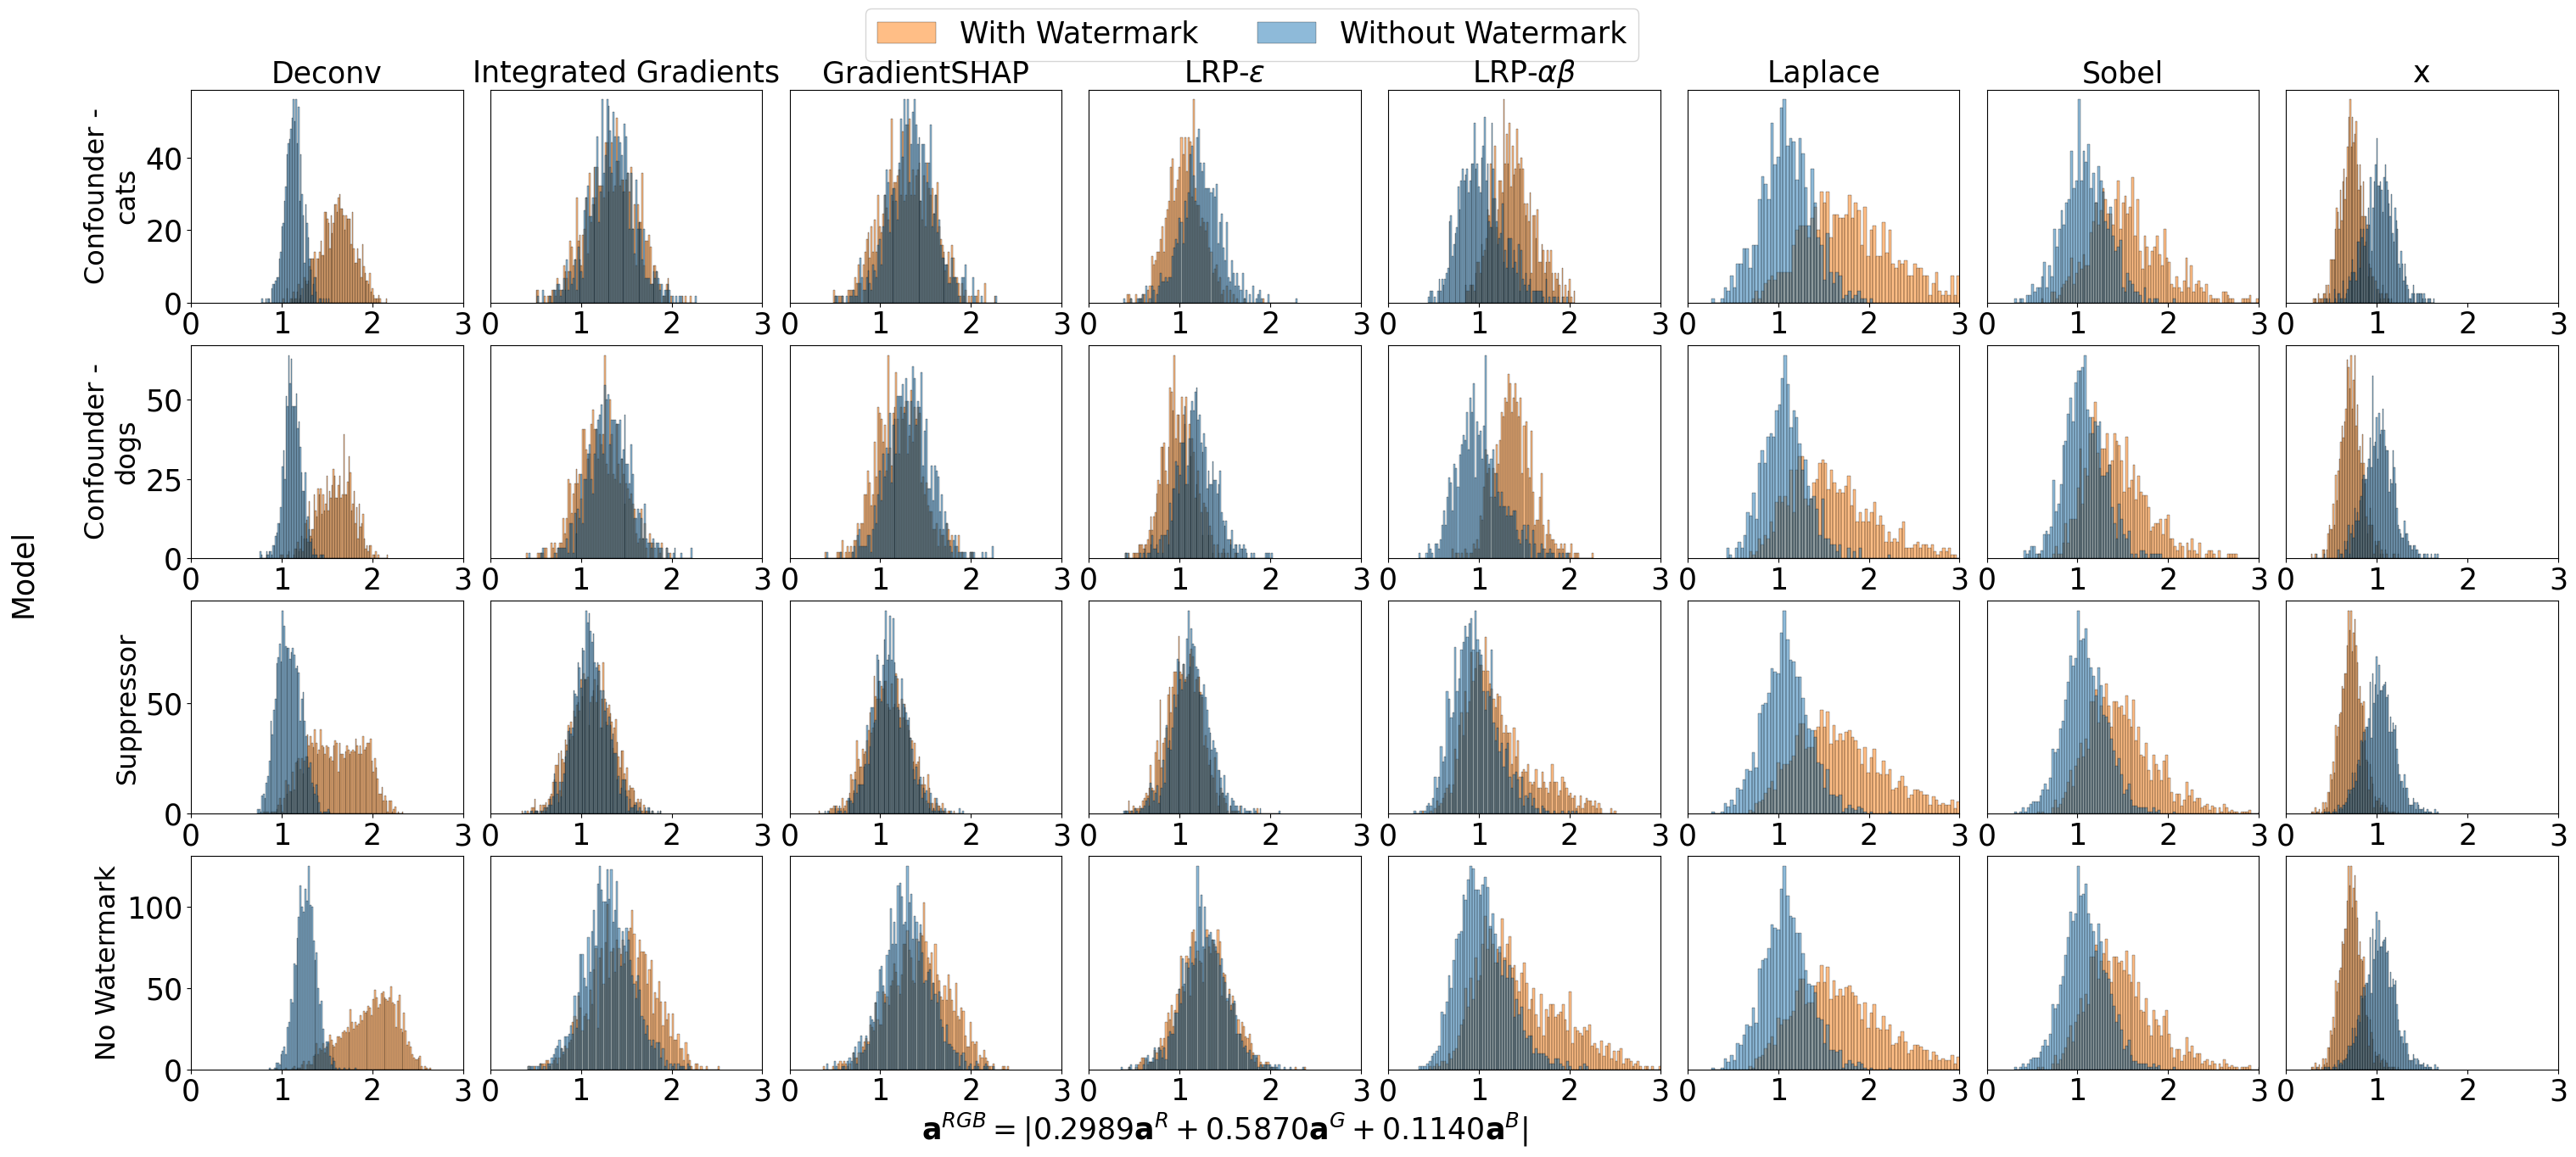

In [190]:
energies_input = (energy_water_conf, energy_water_sup, energy_water_no, energy_no_water_conf, energy_no_water_sup, energy_no_water_no)

energies = get_energies(energies_input)

plot_watermarks_energies(energies)

1800
1800
1800
1800
1800
1800
1800
1800


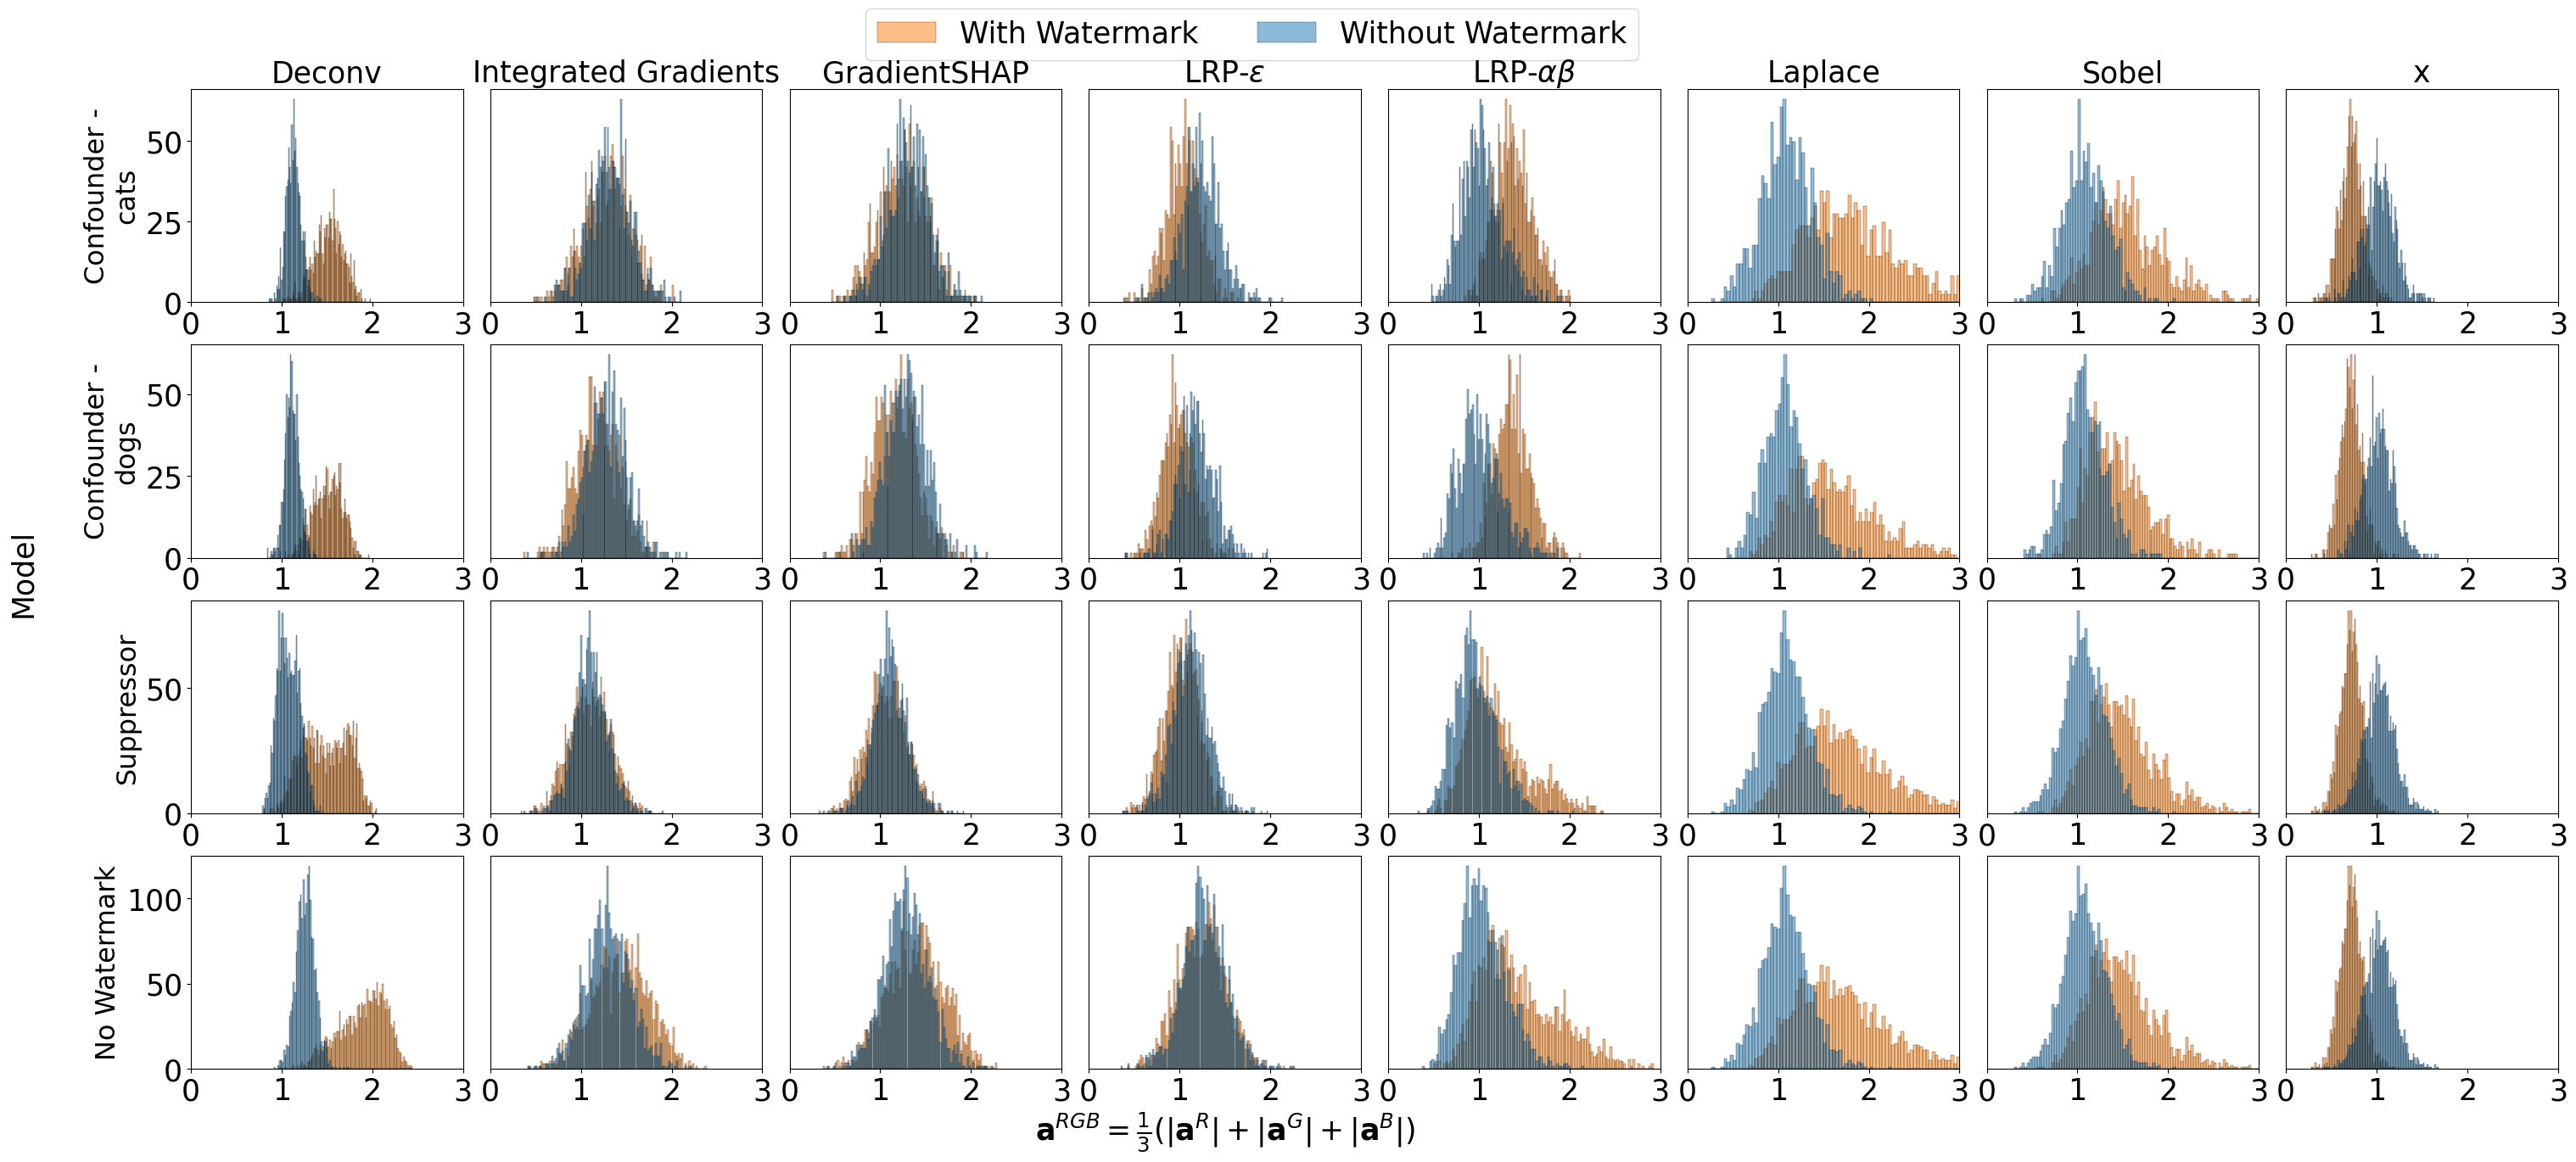

In [191]:
energies_input_norm = (energy_water_conf_norm, energy_water_sup_norm, energy_water_no_norm, energy_no_water_conf_norm, energy_no_water_sup_norm, energy_no_water_no_norm)

energies_norm = get_energies(energies_input_norm)

plot_watermarks_energies(energies_norm, norm=True)